In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


# Importación del dataset

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
hd_features = heart_disease.data.features
hd_target = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(hd_target)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

# Exploración Inicial

Con el objetivo de comprender los datos que tenemos en el dataset, haremos una :exploración breve de estos por medio de herramientas que ya conocemos.

## Estadística Descriptiva

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unir features y target para analisis completo
df = pd.concat([hd_features, hd_target], axis=1)

# Seleccion de variables criticas
variables_clave = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

# Media, mediana, desviacion estandar individuales
for col in variables_clave:
    media = df[col].mean()
    mediana = df[col].median()
    std = df[col].std()
    print(f"{col:>10s} -> Media: {media:8.2f} | Mediana: {mediana:8.2f} | Std: {std:8.2f}")

       age -> Media:    54.44 | Mediana:    56.00 | Std:     9.04
      chol -> Media:   246.69 | Mediana:   241.00 | Std:    51.78
  trestbps -> Media:   131.69 | Mediana:   130.00 | Std:    17.60
   thalach -> Media:   149.61 | Mediana:   153.00 | Std:    22.88
   oldpeak -> Media:     1.04 | Mediana:     0.80 | Std:     1.16


De los resultados previos, claramente, más allá de las unidades de medidas distintas, se evidencia que existe disparidad entre las escalas de cada una, por ejemplo vemos de inmediato que `chol` va a predominar por sobre `oldpeak`. En el caso de esta última, recordando que `oldpeak` se define cómo "Depresión del segmento ST inducida por el ejercicio"


## Histogramas

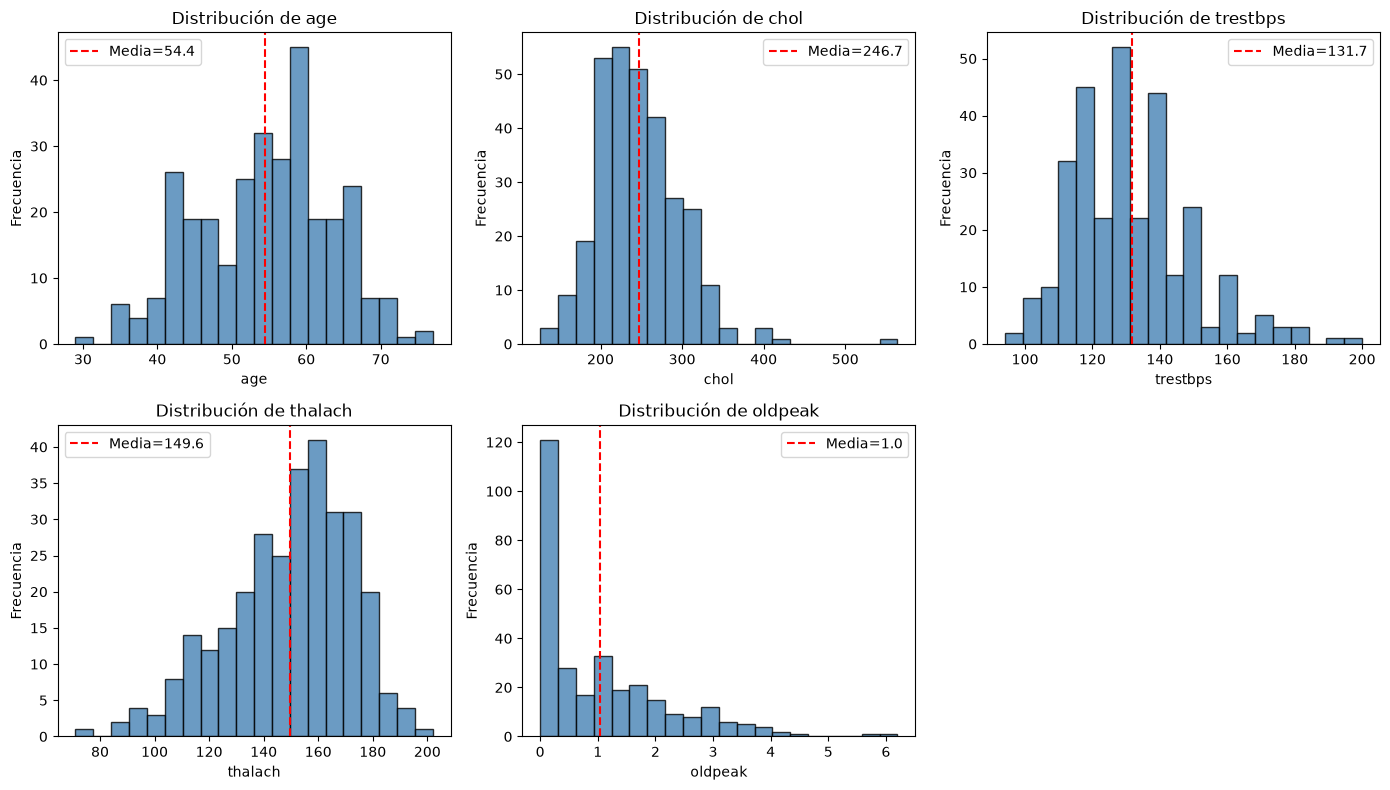

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(variables_clave):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Media={df[col].mean():.1f}')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Quitar ultimo subplot vacio si hay 5 variables
if len(variables_clave) < len(axes):
    for j in range(len(variables_clave), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/histogramas.png', dpi=150)
plt.show()

Nuevamente, los histogramas nos ayudan a ver la frecuencia de valores para ver cómo se distribuyen en el dataset. Vemos que thalach se comporta más cercana a una distribución normal que por ejemplo oldpeak que parece mucho mas sesgado.

## Boxplots

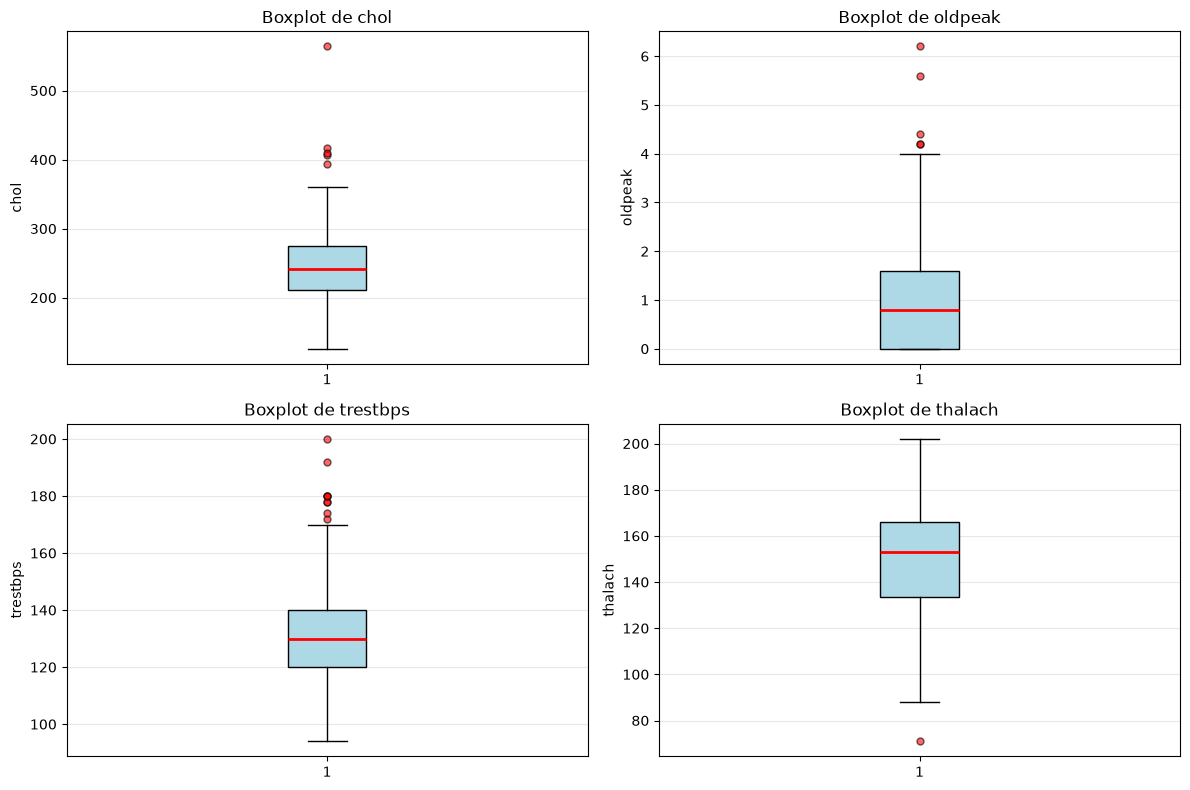

In [5]:
vars_boxplot = ['chol', 'oldpeak', 'trestbps', 'thalach']

# ???
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# codigo en python
for i, col in enumerate(vars_boxplot):
  axes[i].boxplot(df[col].dropna(), orientation='vertical', patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))
  axes[i].set_title(f'Boxplot de {col}')
  axes[i].set_ylabel(col)
  axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/boxplots.png', dpi=150)
plt.show()

### Boxplot combinado

¿Por que usamos gráficos de boxplot? Por que denota la importancia del escalado / estandarizado antes de cualquier algoritmo de caracter lineal como los que vamos a emplear a continuación, ya que al haber muchos outliers en distintas escalas se genera una distorsion del espacio  se nota al tiro nuevamente vemos el mismo ejemplo de las variables `chol` y `oldpeak`.

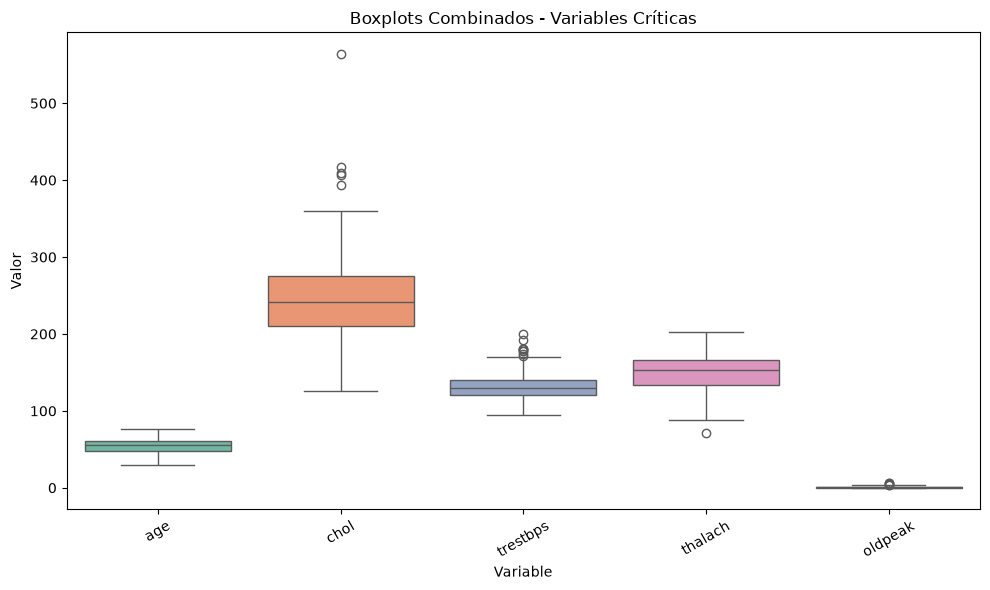

In [6]:
# boxplot combinado todos para uno y uno para todos
plt.figure(figsize=(10, 6))
df_melt = df[variables_clave].melt(var_name='Variable', value_name='Valor')
sns.boxplot(x='Variable', y='Valor', data=df_melt, hue='Variable', legend=False, palette='Set2')
plt.title('Boxplots Combinados - Variables Críticas')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/boxplots_combinados.png', dpi=150)
plt.show()

In [7]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix
      .round(3)
      .mask(corr_matrix.abs().lt(0.3)))

            age    sex     cp  trestbps  chol  fbs  restecg  thalach  exang  \
age       1.000    NaN    NaN       NaN   NaN  NaN      NaN   -0.394    NaN   
sex         NaN  1.000    NaN       NaN   NaN  NaN      NaN      NaN    NaN   
cp          NaN    NaN  1.000       NaN   NaN  NaN      NaN   -0.334  0.384   
trestbps    NaN    NaN    NaN       1.0   NaN  NaN      NaN      NaN    NaN   
chol        NaN    NaN    NaN       NaN   1.0  NaN      NaN      NaN    NaN   
fbs         NaN    NaN    NaN       NaN   NaN  1.0      NaN      NaN    NaN   
restecg     NaN    NaN    NaN       NaN   NaN  NaN      1.0      NaN    NaN   
thalach  -0.394    NaN -0.334       NaN   NaN  NaN      NaN    1.000 -0.378   
exang       NaN    NaN  0.384       NaN   NaN  NaN      NaN   -0.378  1.000   
oldpeak     NaN    NaN    NaN       NaN   NaN  NaN      NaN   -0.343    NaN   
slope       NaN    NaN    NaN       NaN   NaN  NaN      NaN   -0.386    NaN   
ca        0.363    NaN    NaN       NaN   NaN  NaN  

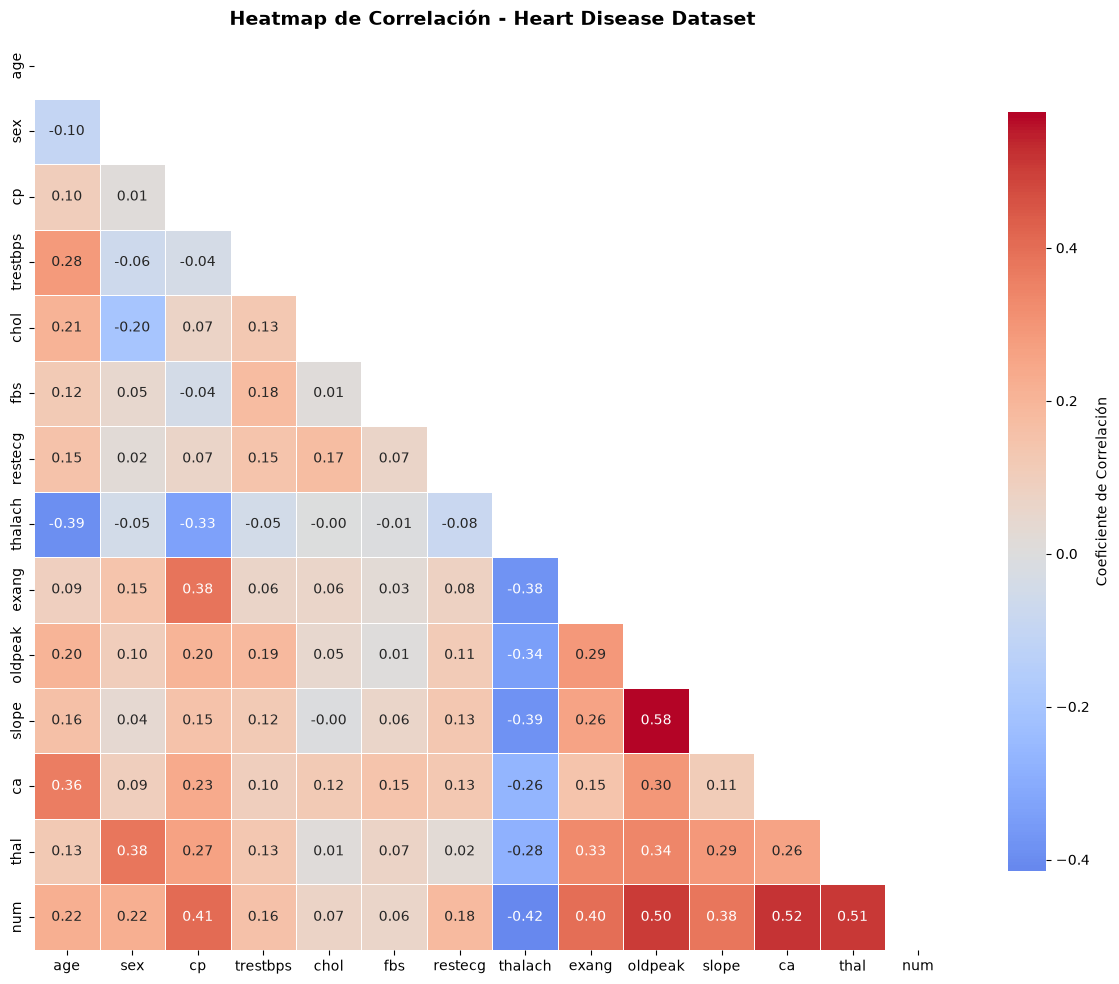

In [8]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación'})
plt.title('Heatmap de Correlación - Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/heatmap_correlacion.png', dpi=150)
plt.show()

**notable**:
- correlacion inversa entre thalach y num => mayores frecuencias cardiacas alcanzadas (quizas con ejercicio habitual), menores diagnósticos de cardiopatía.
- correlacion inversa entre edad y thalach. => mas viejo, corazon trabaja menos
- correlacion directa entre oldpeak y slope, ambas tienen que ver con segmento ST (probablemente datos extraidos de los mismos electrocardiogramas)



# Preprocesamiento de los datos
- **Tratamiento de nulos**: Sí, se detectarán y tratarán
- **Eliminación de outliers**: Sí.
- **Escalamiento/Estandarización**: Sí, se aplicará para asegurar un rendimiento óptimo de los modelos no supervisados.
- **Codificación categórica**: Sí, a las variables clínicas categóricas.

## Tratamiento de nulos

In [9]:
import matplotlib
%matplotlib inline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo

# tratamiento de nulos
# primero tenimos q ver cuantos nulos hay
nulos_antes = df.isnull().sum()
print(f"\nNulos por columna (antes):\n{nulos_antes[nulos_antes > 0]}\n")

# en vez de matar los que tengan variables vacías como son poquitos y para no perder info, se rellenan por valores caracteristicos
# ca: variable discreta (0-3) rellenar con la mediana
mediana_ca = df['ca'].median()
print(f"-> ca: {int(df['ca'].isnull().sum())} nulos rellenados con mediana ({mediana_ca})")
df['ca'] = df['ca'].fillna(mediana_ca)

# thal: categorica (3,6,7) rellenar con la moda
moda_thal = df['thal'].mode()[0]
print(f"-> thal: {int(df['thal'].isnull().sum())} nulos rellenados con moda ({int(moda_thal)})")
df['thal'] = df['thal'].fillna(moda_thal)


Nulos por columna (antes):
ca      4
thal    2
dtype: int64

-> ca: 4 nulos rellenados con mediana (0.0)
-> thal: 2 nulos rellenados con moda (3)


Se encontraron 4 nulos que se rellenan con la mediana, esta es una manera de no perder información al momento de tratar con valores nulos.

## Elimininación de outliers
Técnica IQR: 

> "Para reducir el efecto de los valores extremos muchas veces necesitaremos medidas robustas, que son aquellas que proporcionan una estimación confiable aún ante la presencia de valores atípicos. En este escenario, la mediana resulta ser una buena medida de tendencia central y el IQR, una buena medida de dispersión." (INFERENCIA Y MODELOS ESTADÍSTICOS)

In [10]:
cols_outlier = ['chol', 'trestbps', 'oldpeak', 'thalach', 'age']

outliers_por_columna = {}
total_outliers = set()

for col in cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    mascara_outlier = (df[col] < limite_inf) | (df[col] > limite_sup)
    indices_outlier = df.index[mascara_outlier].tolist()
    outliers_por_columna[col] = len(indices_outlier)
    total_outliers.update(indices_outlier)

    print(f"  {col:>10s}: {len(indices_outlier):3d} outliers  "
          f"(limites: [{limite_inf:.1f}, {limite_sup:.1f}])")

print(f"\n  Total combinado de filas con al menos un outlier: {len(total_outliers)}")

df_clean = df.drop(index=total_outliers).reset_index(drop=True)
print(f"  Filas eliminadas: {len(total_outliers)}")
print(f"  Shape post-outliers: {df_clean.shape}")
print(f"  Target distribucion post-outliers:\n{df_clean['num'].value_counts().sort_index()}\n")

# Guardar target aparte antes de transformaciones
y = df_clean['num']
X = df_clean.drop(columns=['num'])

        chol:   5 outliers  (limites: [115.0, 371.0])
    trestbps:   9 outliers  (limites: [90.0, 170.0])
     oldpeak:   5 outliers  (limites: [-2.4, 4.0])
     thalach:   1 outliers  (limites: [84.8, 214.8])
         age:   0 outliers  (limites: [28.5, 80.5])

  Total combinado de filas con al menos un outlier: 19
  Filas eliminadas: 19
  Shape post-outliers: (284, 14)
  Target distribucion post-outliers:
num
0    158
1     53
2     33
3     29
4     11
Name: count, dtype: int64



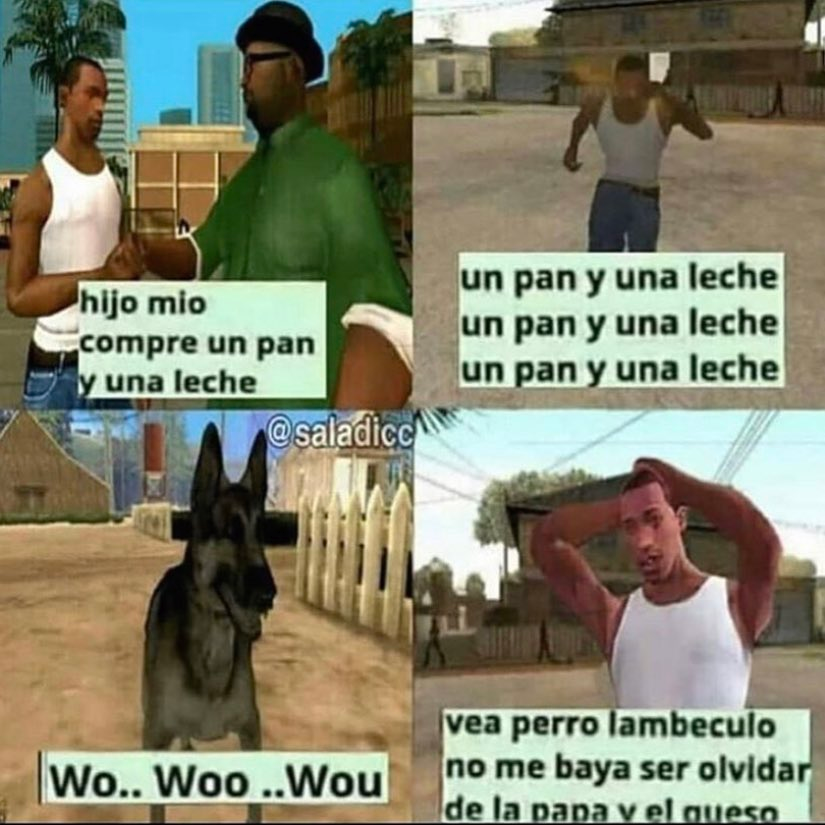

## Codificacion de variables categoricas

Para que PCA y K-Means interpreten correctamente las variables categoricas, se aplica **One-Hot Encoding** (dummy variables):
- **Binarias** (sin cambio): `sex`, `fbs`, `exang`
- **Multi-categoria** (one-hot): `cp` (4), `restecg` (3), `slope` (3), `thal` (3)
- **Continuas** (sin codificar): `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`

> "Imaginemos que tenemos una variable categórica con k niveles. El primer paso consiste en crear k−1 nuevas variables artificiales. A continuación, para cada una de estas nuevas variables, escogemos un nivel diferente de la variable original y asignamos un 1 a todas las observaciones que tengan ese nivel y un 0 a las restantes." (INFERENCIA Y MODELOS ESTADISTICOS)

In [11]:
from sklearn.preprocessing import OneHotEncoder

binarias = ['sex', 'fbs', 'exang']
categoricas_multiclase = ['cp', 'restecg', 'slope', 'thal']
continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_array = encoder.fit_transform(X[categoricas_multiclase])
encoded_cols = encoder.get_feature_names_out(categoricas_multiclase)
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=X.index)

print(f'Columnas generadas: {list(df_encoded.columns)}')

X_pre_escalado = pd.concat([X[continuas], X[binarias], df_encoded], axis=1)
print(f'Shape pre-escalado: {X_pre_escalado.shape}')
print(f'Columnas finales: {list(X_pre_escalado.columns)}')

Columnas generadas: ['cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'slope_3', 'thal_3.0', 'thal_6.0', 'thal_7.0']
Shape pre-escalado: (284, 22)
Columnas finales: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'fbs', 'exang', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'slope_3', 'thal_3.0', 'thal_6.0', 'thal_7.0']


## Escalamiento / Estandarizacion

Se aplica **StandardScaler** (z-score) para que todas las variables tengan media 0 y desviacion estandar 1. Esto es indispensable antes de PCA y K-Means, ya que ambos dependen de distancias euclidianas y serian dominados por las variables de mayor magnitud previamente mencionadas.


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_pre_escalado)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_pre_escalado.columns)

print('Media por columna (debe ~0):')
print(X_scaled.mean().round(4))
print('\nStd por columna (ddof=1, debe ~1):')
print(X_scaled.std().round(4))

Media por columna (debe ~0):
age          0.0
trestbps    -0.0
chol         0.0
thalach      0.0
oldpeak      0.0
ca          -0.0
sex          0.0
fbs         -0.0
exang        0.0
cp_1         0.0
cp_2         0.0
cp_3         0.0
cp_4         0.0
restecg_0    0.0
restecg_1    0.0
restecg_2   -0.0
slope_1     -0.0
slope_2     -0.0
slope_3     -0.0
thal_3.0    -0.0
thal_6.0     0.0
thal_7.0    -0.0
dtype: float64

Std por columna (ddof=1, debe ~1):
age          1.0018
trestbps     1.0018
chol         1.0018
thalach      1.0018
oldpeak      1.0018
ca           1.0018
sex          1.0018
fbs          1.0018
exang        1.0018
cp_1         1.0018
cp_2         1.0018
cp_3         1.0018
cp_4         1.0018
restecg_0    1.0018
restecg_1    1.0018
restecg_2    1.0018
slope_1      1.0018
slope_2      1.0018
slope_3      1.0018
thal_3.0     1.0018
thal_6.0     1.0018
thal_7.0     1.0018
dtype: float64


## Experimentos planificados

| Exp | Reduccion | Clustering |
|---|---|---|
| EX1 | PCA | K-Means |
| EX2 | PCA | OPTICS |
| EX3 | UMAP | K-Means |
| EX4 | UMAP | OPTICS |

# Reduccion de Dimensionalidad: PCA

El **PCA** transforma variables correlacionadas en componentes no correlacionados ordenados por varianza explicada. Cada componente es una combinacion lineal de las originales (autovectores de la matriz de covarianza). Se aplica aqui para condensar las 22 variables y facilitar la visualizacion y el clustering posterior.


In [13]:
from sklearn.decomposition import PCA
import numpy as np

# llamamos pca
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# se guardan las varianzas indivbiduales, el acumulado y los eigenvaules
varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)
autovalores = pca.explained_variance_

# mostrar tabla de varianza!!
print('=== VARIANZA EXPLICADA POR COMPONENTE ===')
for i, (v_ind, v_acum, eig) in enumerate(zip(varianza_individual, varianza_acumulada, autovalores)):
    print(f'PC{i+1:>3d}: {v_ind:.4f} ({v_ind*100:5.1f}%%)  |  acum: {v_acum:.4f} ({v_acum*100:5.1f}%%)  |  eig: {eig:.3f}')

# criterio del 80
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f'\nComponentes para >= 80%: {n_80}')
print(f'  Interpretacion: se necesitan {n_80}/{X_scaled.shape[1]} componentes -> estructura mayoritariamente NO lineal.')

=== VARIANZA EXPLICADA POR COMPONENTE ===
PC  1: 0.1980 ( 19.8%%)  |  acum: 0.1980 ( 19.8%%)  |  eig: 4.372
PC  2: 0.0973 (  9.7%%)  |  acum: 0.2953 ( 29.5%%)  |  eig: 2.147
PC  3: 0.0790 (  7.9%%)  |  acum: 0.3743 ( 37.4%%)  |  eig: 1.744
PC  4: 0.0710 (  7.1%%)  |  acum: 0.4453 ( 44.5%%)  |  eig: 1.569
PC  5: 0.0656 (  6.6%%)  |  acum: 0.5109 ( 51.1%%)  |  eig: 1.447
PC  6: 0.0590 (  5.9%%)  |  acum: 0.5699 ( 57.0%%)  |  eig: 1.303
PC  7: 0.0541 (  5.4%%)  |  acum: 0.6240 ( 62.4%%)  |  eig: 1.193
PC  8: 0.0514 (  5.1%%)  |  acum: 0.6753 ( 67.5%%)  |  eig: 1.134
PC  9: 0.0471 (  4.7%%)  |  acum: 0.7224 ( 72.2%%)  |  eig: 1.040
PC 10: 0.0457 (  4.6%%)  |  acum: 0.7682 ( 76.8%%)  |  eig: 1.010
PC 11: 0.0407 (  4.1%%)  |  acum: 0.8089 ( 80.9%%)  |  eig: 0.898
PC 12: 0.0380 (  3.8%%)  |  acum: 0.8469 ( 84.7%%)  |  eig: 0.839
PC 13: 0.0318 (  3.2%%)  |  acum: 0.8787 ( 87.9%%)  |  eig: 0.703
PC 14: 0.0301 (  3.0%%)  |  acum: 0.9088 ( 90.9%%)  |  eig: 0.665
PC 15: 0.0291 (  2.9%%)  |  acum: 

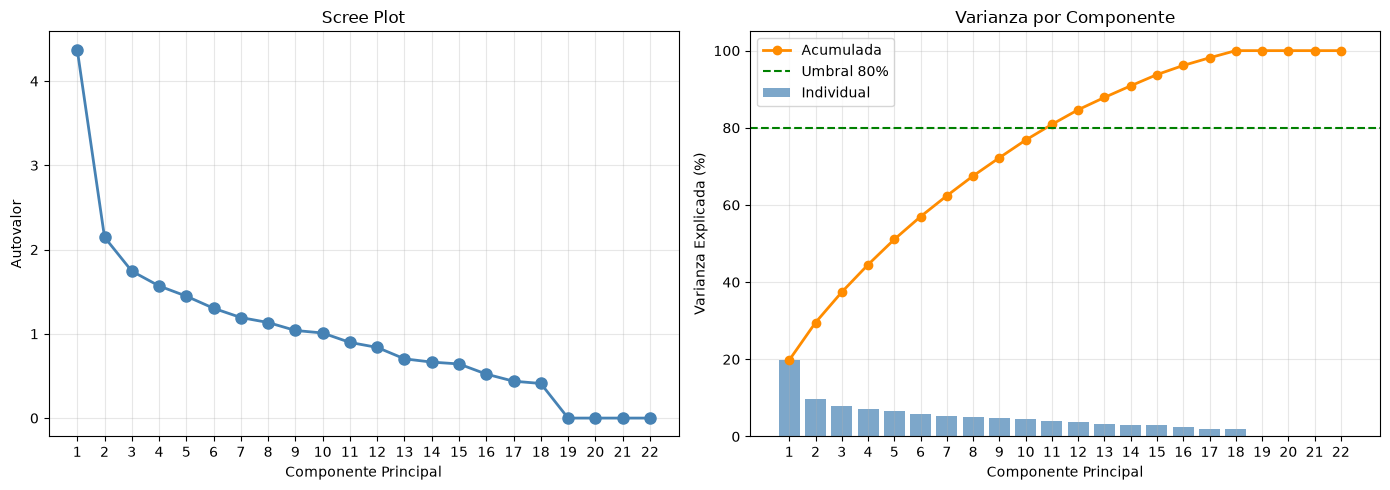

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_comps = len(varianza_individual)
comps = range(1, n_comps + 1)

# Scree Plot
ax1.plot(comps, autovalores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Autovalor')
ax1.set_title('Scree Plot')
ax1.grid(alpha=0.3)
ax1.set_xticks(comps)

# Varianza acumulada
ax2.bar(comps, varianza_individual * 100, color='steelblue', alpha=0.7, label='Individual')
ax2.plot(comps, varianza_acumulada * 100, 'o-', color='darkorange', linewidth=2, markersize=6, label='Acumulada')
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='Umbral 80%')
ax2.set_xlabel('Componente Principal')
ax2.set_ylabel('Varianza Explicada (%)')
ax2.set_title('Varianza por Componente')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(comps)

plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_varianza.png', dpi=150)
plt.show()

=== LOADINGS (primeros 5 PCs) ===
             PC1    PC2    PC3    PC4    PC5
age       -0.190 -0.210 -0.131 -0.083  0.481
trestbps  -0.094 -0.227 -0.043  0.241  0.326
chol      -0.033 -0.188  0.148 -0.231  0.292
thalach    0.317  0.013  0.167  0.181 -0.085
oldpeak   -0.299  0.015 -0.203  0.142 -0.052
ca        -0.216 -0.078  0.059 -0.091  0.404
sex       -0.148  0.189  0.288  0.379 -0.065
fbs       -0.040 -0.117 -0.021  0.316  0.256
exang     -0.283  0.090  0.125 -0.123 -0.105
cp_1      -0.004 -0.119 -0.070  0.403  0.010
cp_2       0.201  0.029  0.140 -0.043 -0.104
cp_3       0.167 -0.046 -0.382  0.107  0.152
cp_4      -0.303  0.084  0.278 -0.281 -0.064
restecg_0  0.152  0.554 -0.211 -0.015  0.235
restecg_1 -0.035 -0.017 -0.216 -0.159  0.015
restecg_2 -0.146 -0.551  0.247  0.042 -0.237
slope_1    0.326  0.007  0.396 -0.011  0.275
slope_2   -0.308  0.006 -0.360 -0.164 -0.219
slope_3   -0.041 -0.029 -0.080  0.377 -0.122
thal_3.0   0.333 -0.279 -0.173 -0.206 -0.083
thal_6.0  -0.115 -0.0

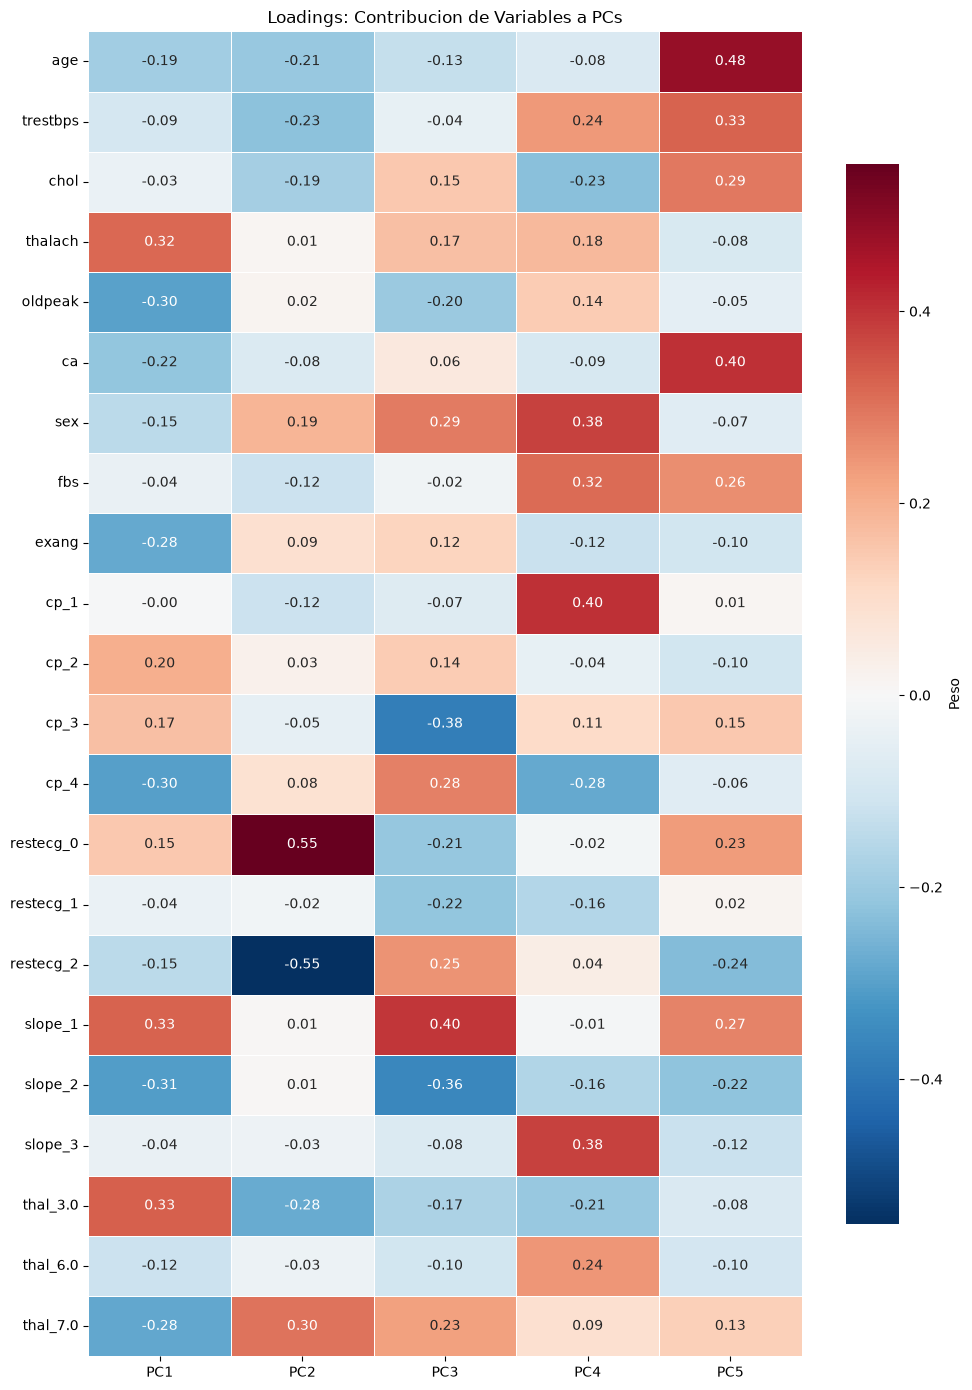

In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comps)],
    index=X_scaled.columns
)

print('=== LOADINGS (primeros 5 PCs) ===')
print(loadings.iloc[:, :5].round(3))

plt.figure(figsize=(10, 14))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Peso'})
plt.title('Loadings: Contribucion de Variables a PCs')
plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_loadings.png', dpi=150)
plt.show()

Los **loadings** es una matriz que indican la ponderación de las variables dentro de las componentes principales, vale decir:
- Si el valor es mayor que 0, entonces se da a entender que es una correlación positiva respecto de la PC
- En cambio, si es menor que 0, entonces sería una correlación negativa de la PC

De nuestro resultado, evidenciado con el heatmap, vemos:
- PC1: hay una fuerte correlación positiva para las variables
    - thalach: Frecuencia cardiaca ascendente
    - thal_3.0: Frecuencia cardiaca máxima dentro del intervalo normal
    - slope_1: Segmento ST normal, dentro de lo esperado

De esto, vemos que PC1 se puede interpretar de cierta medida cómo un "indicador de normalidad/salud cardiaca".

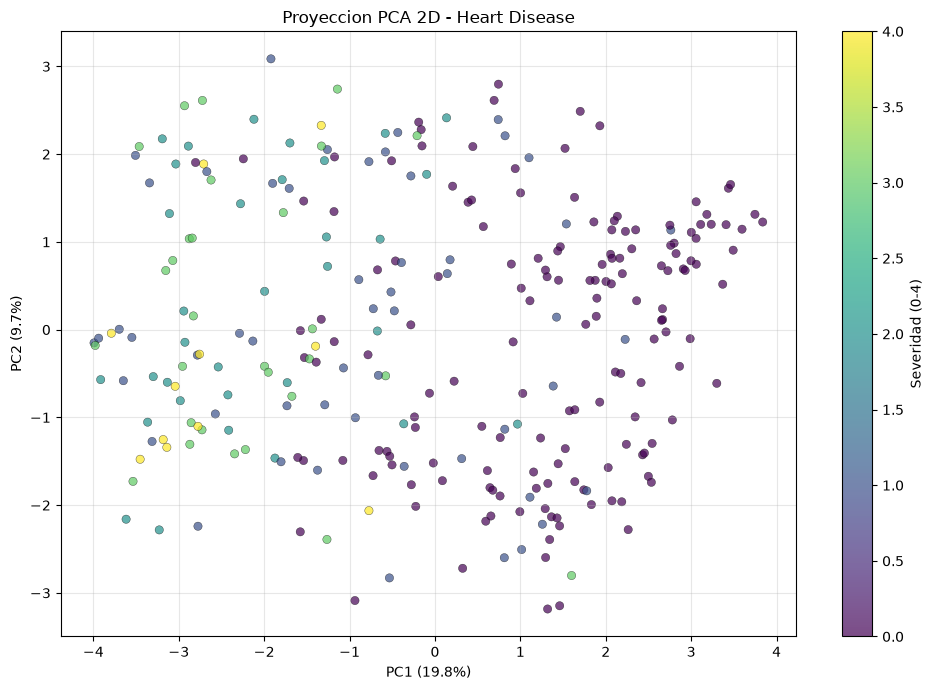

Varianza explicada en 2D: 29.5%


In [16]:
X_pca_2d = X_pca[:, :2]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
plt.xlabel(f'PC1 ({varianza_individual[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({varianza_individual[1]*100:.1f}%)')
plt.title('Proyeccion PCA 2D - Heart Disease')
cbar = plt.colorbar(scatter, label='Severidad (0-4)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_proyeccion_2d.png', dpi=150)
plt.show()

print(f'Varianza explicada en 2D: {varianza_acumulada[1]*100:.1f}%')

A modo de reflexión, vemos que PCA pierde su efectividad con este dataset, evidenciado por la cantidad de componentes principales que se necesitan para cubrir por lo menos un 80% de la varianza explicada, siendo 11 determinada usando método del codo. 

Es probable que PCA haya resultado ineficiente, ya que el objetivo es tener una visualización de a lo más 3 compoenentes. Debido a la posible relación no lineal entre variables y otros varios factores que se pueden explicar de mejor manera utilizando otros métodos.

A continuación, veremos otro método de reducción de dimensionalidad.

# Reduccion de Dimensionalidad: UMAP

**UMAP** es una tecnica no lineal que construye un grafo de k-vecinos en alta dimension y lo optimiza en baja dimension. Se contrasta con PCA para evaluar si existen estructuras no lineales que PCA no captura.

Hiperparametros: `n_neighbors=15`, `min_dist=0.1`, `n_components=2`.

## Tabla Comparativa PCA vs UMAP

| Criterio | PCA | UMAP |
|---|---|---|
| **Interpretabilidad** | Alta (autovectores) | Baja (ejes sin significado) |
| **Preservacion global** | Alta (maximiza varianza) | Media-Alta |
| **Preservacion local** | Baja | Alta (grafo k-NN) |
| **Separacion visual** | Moderada | Alta (clusters nitidos) |
| **Tiempo computacional** | Bajo (SVD) | Medio (grafos + SGD) |


In [17]:
# Asegurar numpy compatible con numba/umap
import sys, subprocess
try:
    import numpy as np
    if np.__version__ >= '2.5':
        print(f'Reinstalando numpy compatible (actual: {np.__version__})...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=2.0,<2.5', '--quiet'])
        print('Hecho. Reinicia kernel si numpy ya estaba cargado.')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=2.0,<2.5', '--quiet'])

%pip install umap-learn --quiet
print('umap-learn OK')

Note: you may need to restart the kernel to use updated packages.
umap-learn OK


In [18]:
import numpy as np
import warnings

# ignorar warn de paralelismo, el proyecto es estrictamente serial
warnings.filterwarnings(
    "ignore", 
    message=".*n_jobs value.*overridden to 1 by setting random_state.*"
)


# asumimos que no tenemos umap en caso de fallo
umap_ok = False
try:
    import umap
    print('UMAP import OK')
    umap_ok = True
except ImportError as e:
    print(f'ERROR: {e}')
    print('Ejecuta la celda de instalacion anterior y reinicia el kernel.')

if umap_ok:
    # llmamamos umap con los parametros previamente definidos
    # n vecinos = 15
    # distancia minima = 0.1
    # n componentes = 2
    # seed = 42
    reducer = umap.UMAP(
        n_neighbors=15, min_dist=0.1, n_components=2,
        random_state=42
    )
    X_umap = reducer.fit_transform(X_scaled)
    print(f'Shape UMAP: {X_umap.shape}')
else:
    print('UMAP no disponible. Se saltan las celdas siguientes.')

UMAP import OK
Shape UMAP: (284, 2)


/tmp/ipykernel_6330/2555829255.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


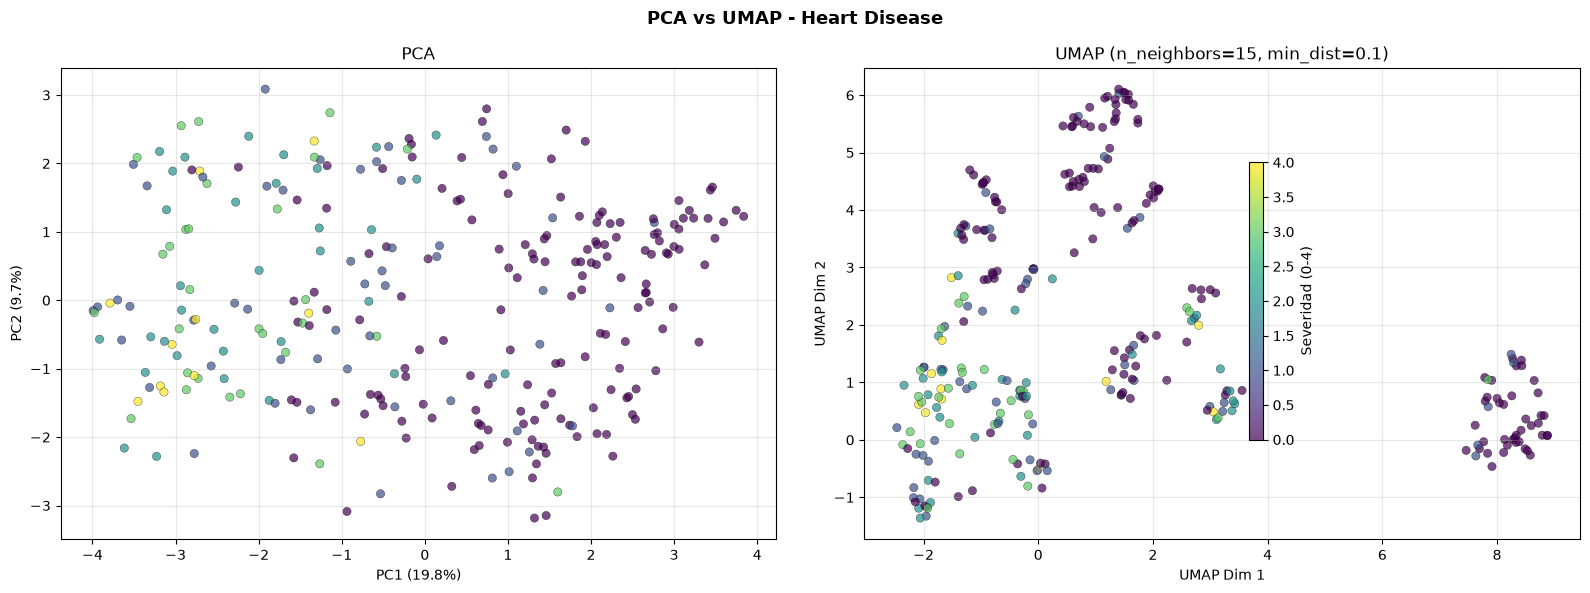

In [19]:
if umap_ok:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[0].set_xlabel(f'PC1 ({varianza_individual[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({varianza_individual[1]*100:.1f}%)')
    axes[0].set_title('PCA')
    axes[0].grid(alpha=0.3)

    sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1],
                           c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[1].set_xlabel('UMAP Dim 1')
    axes[1].set_ylabel('UMAP Dim 2')
    axes[1].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
    axes[1].grid(alpha=0.3)

    cbar = fig.colorbar(sc2, ax=axes, label='Severidad (0-4)', shrink=0.6)
    plt.suptitle('PCA vs UMAP - Heart Disease', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/3_transformacion/pca_vs_umap.png', dpi=150)
    plt.show()
else:
    print('UMAP no disponible.')

Es clara la diferencia entre PCA y UMAP
Notar que UMAP, **las dimensiones mostradas (a diferencia de PCA) NO son interpretables**, cómo se hizo el ejercicio anteriormente de hacer sentido de la PC1.

Por otro lado, vemos que contrastado con la Severidad (num) cómo medida de coloreo, se evidencia la correlación de los puntos en varios sectores de riesgo:
- Abajo a la izquierda se ve una isla con varios puntos de color amarillo, representando enfermedad severa mientras que arriba
- A la derecha se ven islas predominantemente más azules indicando menor severidad coronaria.

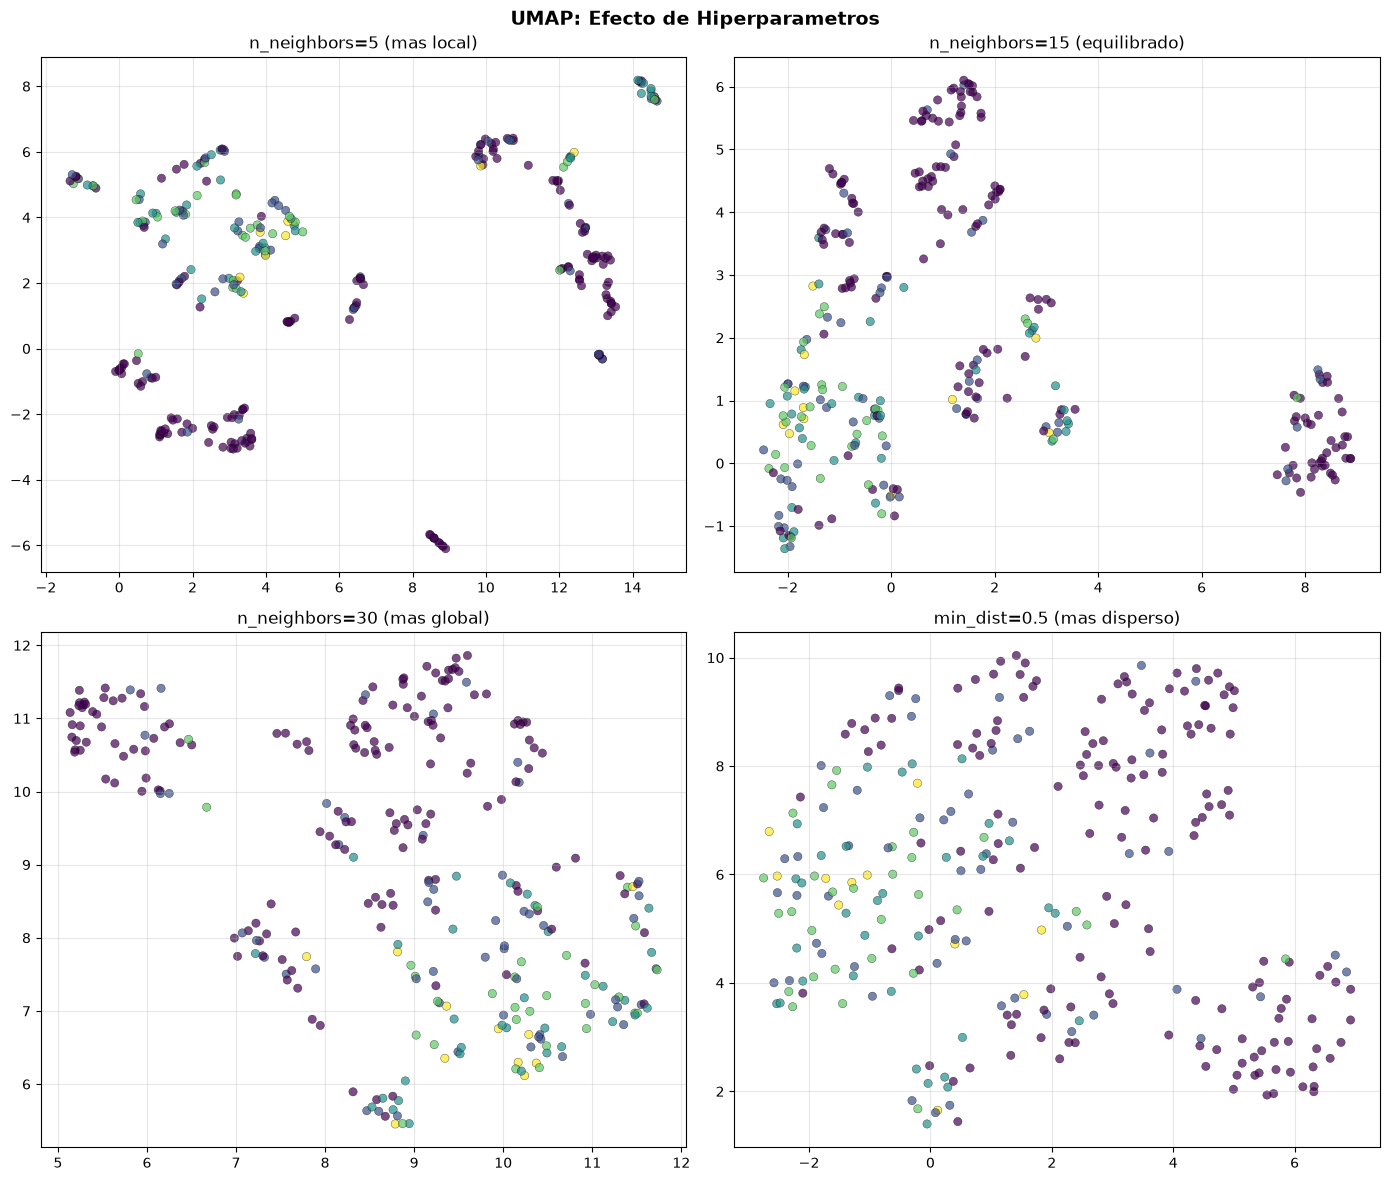

In [20]:
if umap_ok:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    configs = [
        (5, 0.1, 'n_neighbors=5 (mas local)'),
        (15, 0.1, 'n_neighbors=15 (equilibrado)'),
        (30, 0.1, 'n_neighbors=30 (mas global)'),
        (15, 0.5, 'min_dist=0.5 (mas disperso)'),
    ]

    for i, (n_neigh, m_dist, title) in enumerate(configs):
        r = umap.UMAP(n_neighbors=n_neigh, min_dist=m_dist, n_components=2, random_state=42)
        proj = r.fit_transform(X_scaled)
        axes[i].scatter(proj[:, 0], proj[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
        axes[i].set_title(title)
        axes[i].grid(alpha=0.3)

    plt.suptitle('UMAP: Efecto de Hiperparametros', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/3_transformacion/umap_hiperparametros.png', dpi=150)
    plt.show()
else:
    print('UMAP no disponible.')

Se hizo la evaluación de n vecinos distintos y otro valor de distancia mínima:
- Para el valor de n_neighbours
    - Con 5: Se evidencia una estructura local más fuerte pero con sobrelape evidente, lo que dificulta la visibilidad de los puntos
    - Con 30: Se pierde, aún que no dramaticamente, la estructura local en favor de una estructura global.

- Para min dist mas grande, se nota una dispersión importante de los puntos, se eligió el valor 0.1 por convención, por defecto UMAP usa el valor 0.1.

# Clustering particional: K-Means

**K-Means** es un algoritmo de particionamiento que minimiza iterativamente la **inercia** (suma de distancias euclidianas al cuadrado de cada punto a su centroide). A diferencia de OPTICS, exige fijar el numero de clusters `k` a priori. Aqui se selecciona con dos criterios complementarios:

- **Metodo del codo**: el `k` a partir del cual la inercia deja de decrecer significativamente.
- **Silhouette Score**: el `k` que maximiza la cohesion y separacion media de los clusters.

## Experimentos del plan experimental

| Exp | Reduccion | Clustering | Se implementa en |
|---|---|---|---|
| EX1 | PCA | K-Means | seleccion de `k` y clusters sobre `X_pca_2d` |
| EX3 | UMAP | K-Means | seleccion de `k` y clusters sobre `X_umap` |

## Métricas de evaluación

| Métrica | Sentido óptimo | Que mide |
|---|---|---|
| **Silhouette** | Mayor | Cohesión y separación media de los clusters |
| **Davies-Bouldin** | Menor | Razon dispersion intra-cluster vs. distancia entre centroides |
| **Calinski-Harabasz** | Mayor | Razon dispersion entre grupos / dispersion intra-grupo |
| **ARI** | Mayor | Concordancia con el ground truth `y` (severidad 0-4), ajustada al azar |
| **Dunn** | Mayor | Minima distancia entre clusters / maximo diametro interno |



In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from scipy.spatial.distance import pdist, squareform


def dunn_index(X, labels):
    """Dunn index: min distancia entre clusters / max diametro interno."""
    unique = np.unique(labels)
    if len(unique) < 2:
        return np.nan
    dist = squareform(pdist(X))
    max_intra, min_inter = 0.0, np.inf
    for a in unique:
        mask_a = labels == a
        if mask_a.sum() > 1:
            max_intra = max(max_intra, np.max(dist[np.ix_(mask_a, mask_a)]))
        for b in unique:
            if a < b:
                min_inter = min(min_inter, np.min(dist[np.ix_(mask_a, labels == b)]))
    return min_inter / max_intra if max_intra > 0 else np.nan


def grid_kmeans(X, k_range=range(2, 13), seed=42):
    filas, modelos = [], {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10, max_iter=1000)
        km.fit(X)
        modelos[k] = km
        filas.append({
            'k': k,
            'Inercia': km.inertia_,
            'Silhouette': silhouette_score(X, km.labels_),
            'Davies-Bouldin': davies_bouldin_score(X, km.labels_),
            'Calinski-Harabasz': calinski_harabasz_score(X, km.labels_),
            'ARI': adjusted_rand_score(np.asarray(y), km.labels_),
            'Dunn': dunn_index(X, km.labels_),
        })
    return pd.DataFrame(filas).set_index('k'), modelos


def plot_seleccion_k(grid, titulo, filename):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    paneles = [
        (axes[0, 0], 'Inercia', 'o-', 'Codo (menor pendiente)'),
        (axes[0, 1], 'Silhouette', 'o-', 'Maximo'),
        (axes[1, 0], 'Davies-Bouldin', 's-', 'Minimo'),
        (axes[1, 1], 'Calinski-Harabasz', 'D-', 'Maximo'),
    ]
    for ax, col, marker, crit in paneles:
        ax.plot(grid.index, grid[col], marker, color='steelblue', linewidth=2, markersize=7)
        ax.set_xlabel('k')
        ax.set_ylabel('Inercia (WCSS)' if col == 'Inercia' else col)
        ax.set_title(f'{col} por k  (criterio: {crit})')
        ax.grid(alpha=0.3)
        ax.set_xticks(list(grid.index))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


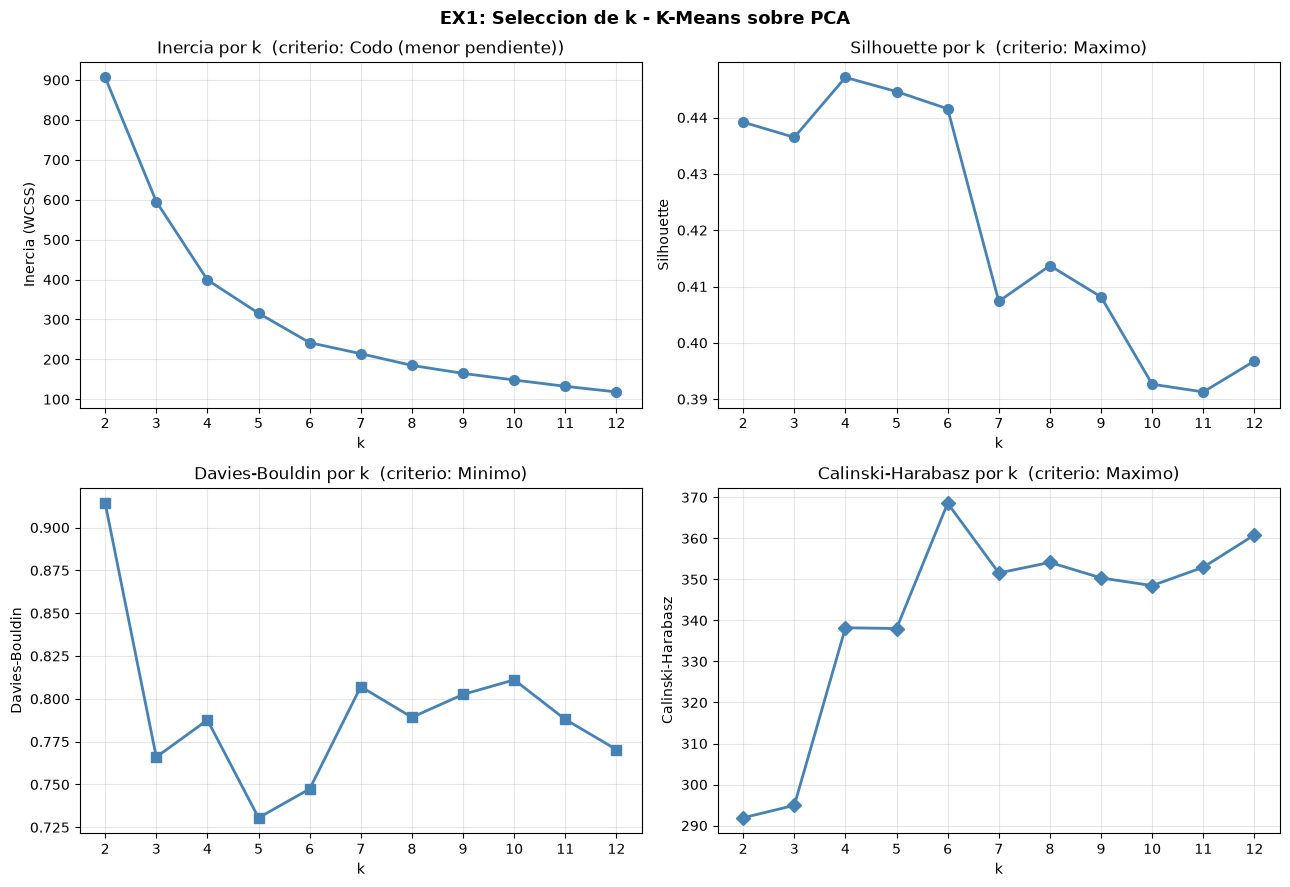

=== EX1: PCA + K-Means, metricas por k ===
    Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI   Dunn
k                                                                       
2   906.526       0.439           0.914            291.903  0.266  0.052
3   595.297       0.436           0.766            294.924  0.165  0.041
4   399.005       0.447           0.788            338.214  0.177  0.046
5   315.564       0.445           0.731            338.030  0.186  0.045
6   241.829       0.442           0.747            368.566  0.172  0.053
7   214.145       0.407           0.807            351.565  0.111  0.066
8   184.823       0.414           0.789            354.143  0.109  0.047
9   164.836       0.408           0.803            350.359  0.075  0.038
10  148.222       0.393           0.811            348.490  0.085  0.040
11  132.448       0.391           0.788            352.966  0.087  0.033
12  118.317       0.397           0.770            360.839  0.088  0.056


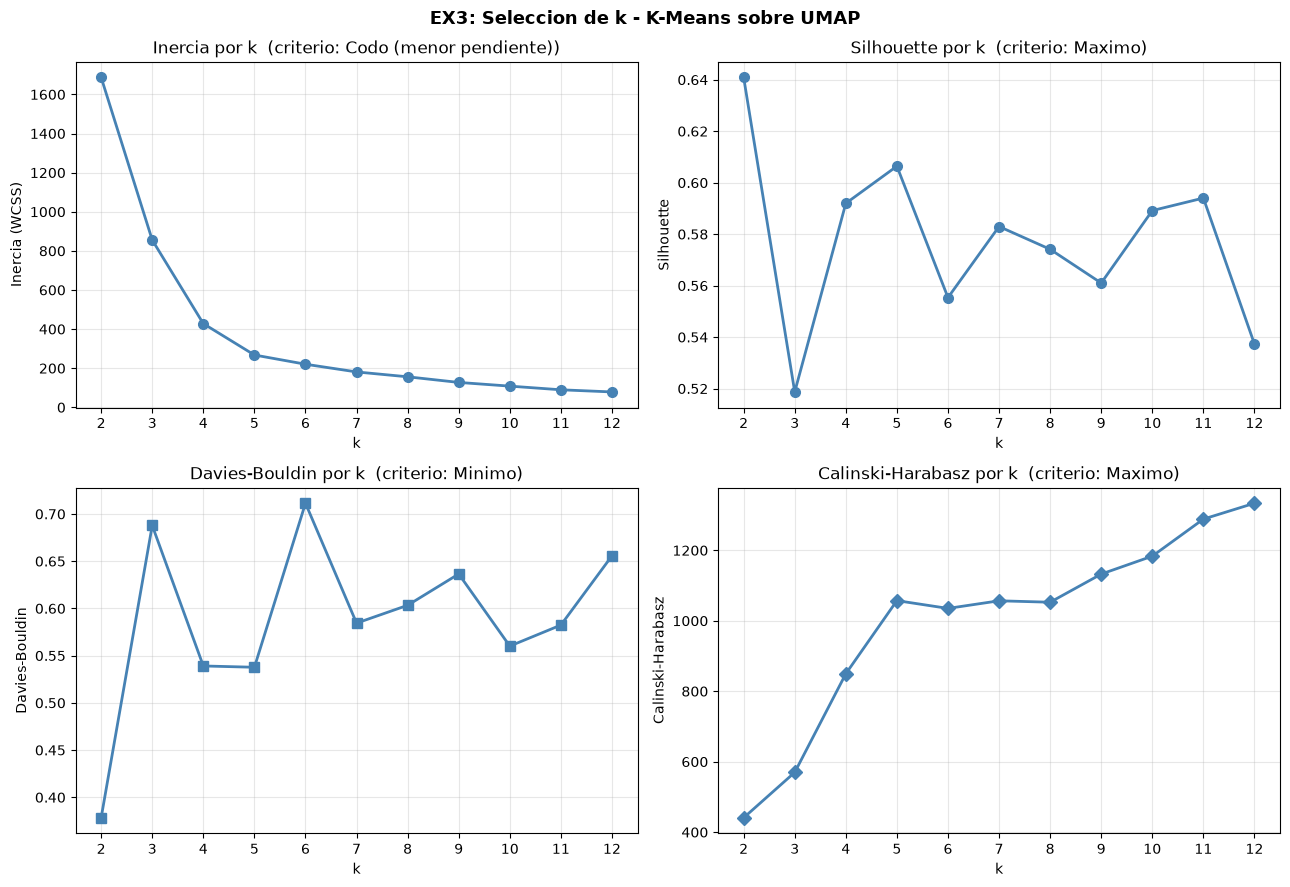


=== EX3: UMAP + K-Means, metricas por k ===
     Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI   Dunn
k                                                                        
2   1687.062       0.641           0.378            440.848 -0.086  0.492
3    855.475       0.519           0.688            569.728  0.076  0.020
4    428.023       0.592           0.539            849.638  0.144  0.028
5    267.646       0.606           0.538           1057.218  0.074  0.042
6    220.439       0.555           0.711           1035.125  0.112  0.101
7    181.020       0.583           0.584           1056.717  0.123  0.105
8    156.130       0.574           0.603           1052.646  0.132  0.105
9    127.389       0.561           0.636           1132.545  0.084  0.068
10   108.457       0.589           0.560           1183.444  0.085  0.068
11    89.715       0.594           0.582           1288.606  0.085  0.086
12    78.720       0.537           0.656           1333.643  0.062 

In [22]:
grid_pca, modelos_pca = grid_kmeans(X_pca_2d)
plot_seleccion_k(grid_pca, 'EX1: Seleccion de k - K-Means sobre PCA', 'plots/4_mineria/kmeans_codo_pca.png')
print('=== EX1: PCA + K-Means, metricas por k ===')
print(grid_pca.round(3))

if umap_ok:
    grid_umap, modelos_umap = grid_kmeans(X_umap)
    plot_seleccion_k(grid_umap, 'EX3: Seleccion de k - K-Means sobre UMAP', 'plots/4_mineria/kmeans_codo_umap.png')
    print('\n=== EX3: UMAP + K-Means, metricas por k ===')
    print(grid_umap.round(3))
else:
    print('UMAP no disponible: EX3 omitido.')


In [23]:
k_opt_pca = grid_pca['Silhouette'].idxmax()
print(f'k optimo en PCA segun Silhouette: {k_opt_pca}')
print(f'k optimo en PCA segun Calinski-Harabasz: {grid_pca["Calinski-Harabasz"].idxmax()}')
print(f'k optimo en PCA segun Davies-Bouldin: {grid_pca["Davies-Bouldin"].idxmin()}')

if umap_ok:
    k_opt_umap = grid_umap['Silhouette'].idxmax()
    print(f'k optimo en UMAP segun Silhouette: {k_opt_umap}')
    print(f'k optimo en UMAP segun Calinski-Harabasz: {grid_umap["Calinski-Harabasz"].idxmax()}')
    print(f'k optimo en UMAP segun Davies-Bouldin: {grid_umap["Davies-Bouldin"].idxmin()}')
    pares = [(k_opt_pca, modelos_pca[k_opt_pca], X_pca_2d, 'PCA'),
             (k_opt_umap, modelos_umap[k_opt_umap], X_umap, 'UMAP')]
else:
    k_opt_umap = None
    print('UMAP no disponible: EX3 omitido.')
    pares = [(k_opt_pca, modelos_pca[k_opt_pca], X_pca_2d, 'PCA')]


k optimo en PCA segun Silhouette: 4
k optimo en PCA segun Calinski-Harabasz: 6
k optimo en PCA segun Davies-Bouldin: 5
k optimo en UMAP segun Silhouette: 2
k optimo en UMAP segun Calinski-Harabasz: 12
k optimo en UMAP segun Davies-Bouldin: 2


Tanto de los resultados gráficos cómo numéricos, vemos lo siguiente:

**En PCA:**
- Con el método del codo, el óptimo es 4
- Con la métrica Silhoutte, el óptimo es 4
- Con Calinski-Harabasz es 6
- Con Davies-Bouldin: 5

**En UMAP:**
- Con el método del codo, el óptimo es 4
- Con la métrica Silhoutte, el óptimo es 11
- Con Calinski-Harabasz es 12
- Con Davies-Bouldin: 2

Cómo no cambia la función objetivo, se espera que independiente del método de reducción de dimensionalidad, se mantenga el óptimo de 4.

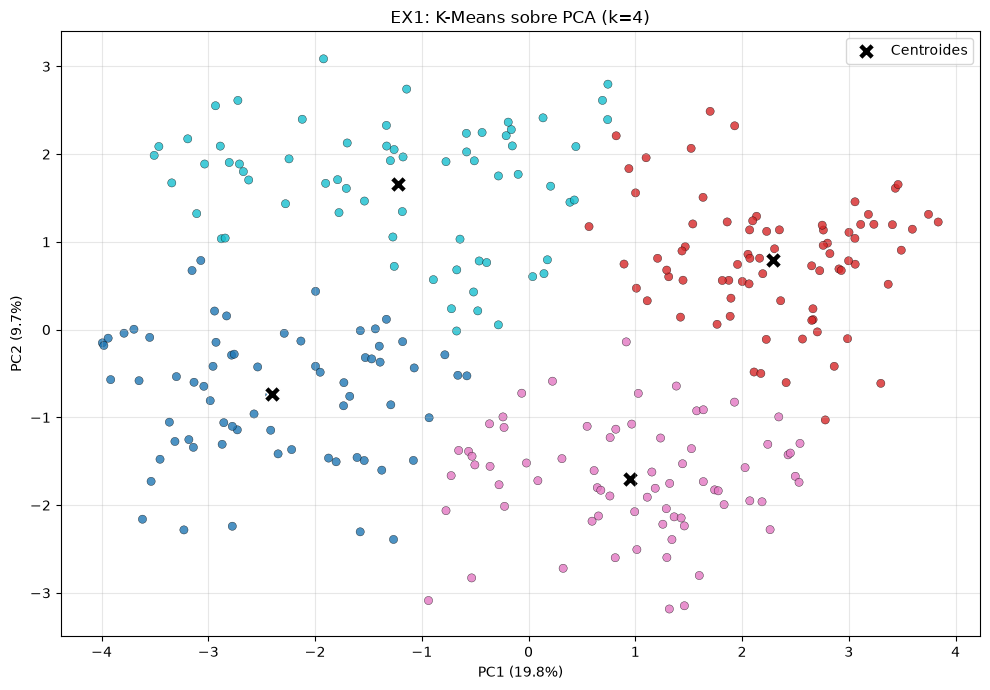

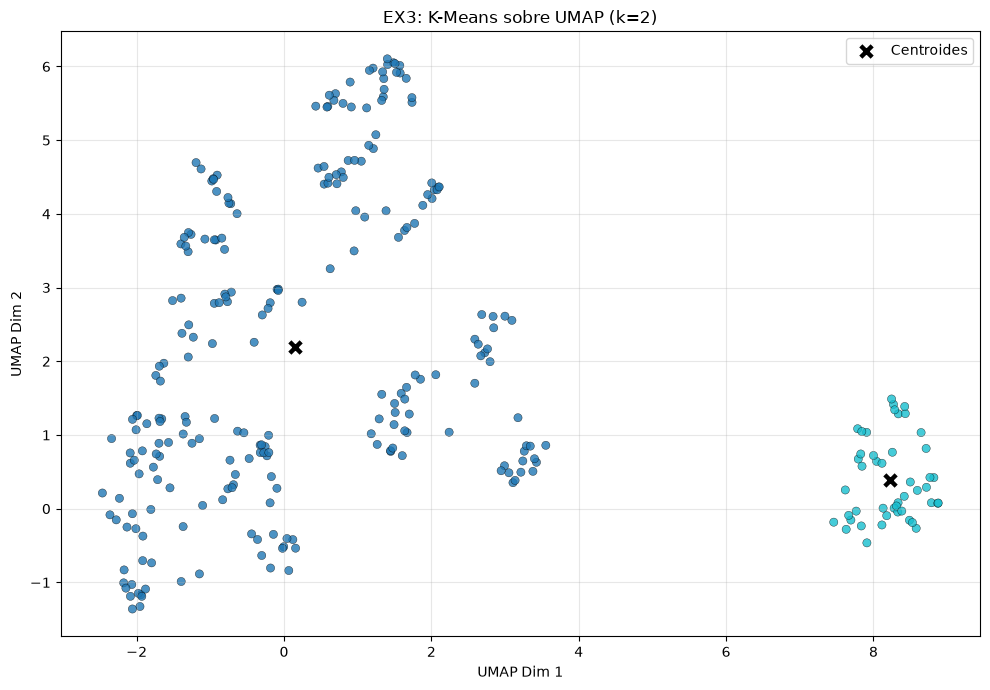

In [24]:
km_pca = modelos_pca[k_opt_pca]
km_umap = modelos_umap[k_opt_umap] if umap_ok else None

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=km_pca.labels_, cmap='tab10',
           alpha=0.8, edgecolors='black', linewidth=0.3, s=35)
ax.scatter(km_pca.cluster_centers_[:, 0], km_pca.cluster_centers_[:, 1],
           marker='X', c='black', s=140, edgecolors='white', linewidth=1, label='Centroides')
ax.set_xlabel(f'PC1 ({varianza_individual[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({varianza_individual[1]*100:.1f}%)')
ax.set_title(f'EX1: K-Means sobre PCA (k={k_opt_pca})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/4_mineria/kmeans_pca.png', dpi=150)
plt.show()

if umap_ok:
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=km_umap.labels_, cmap='tab10',
               alpha=0.8, edgecolors='black', linewidth=0.3, s=35)
    ax.scatter(km_umap.cluster_centers_[:, 0], km_umap.cluster_centers_[:, 1],
               marker='X', c='black', s=140, edgecolors='white', linewidth=1, label='Centroides')
    ax.set_xlabel('UMAP Dim 1')
    ax.set_ylabel('UMAP Dim 2')
    ax.set_title(f'EX3: K-Means sobre UMAP (k={k_opt_umap})')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/4_mineria/kmeans_umap.png', dpi=150)
    plt.show()


In [25]:
print('=== INTERPRETACION DE CENTROIDES (EX1: PCA + K-Means) ===')
print('Los centroides se reconstruyen al espacio original (inversa de PCA + inversa del scaler).\n')

centroides_pad = np.zeros((k_opt_pca, X_pca.shape[1]))
centroides_pad[:, :2] = km_pca.cluster_centers_
centroides_orig = scaler.inverse_transform(pca.inverse_transform(centroides_pad))
df_centroides = pd.DataFrame(centroides_orig, columns=X_pre_escalado.columns)
df_centroides_z = pd.DataFrame(pca.inverse_transform(centroides_pad),
                               columns=X_scaled.columns)

continuas_orig = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
perfil_cluster = X_pre_escalado.copy()
perfil_cluster['cluster'] = km_pca.labels_

print('--- Perfil medio por cluster (variables continuas, unidades originales) ---')
print(perfil_cluster.groupby('cluster')[continuas_orig].mean().round(2))

print('\n--- Distribucion de severidad (target) por cluster ---')
tabla_sev = pd.crosstab(km_pca.labels_, y)
tabla_sev['total'] = tabla_sev.sum(axis=1)
print(tabla_sev)

print('\n--- Centroides reconstruidos (unidades originales) ---')
print(df_centroides.round(2))

print('\n--- Top 5 variables por centroide (|z-score|, mayor contribucion) ---')
for i in range(k_opt_pca):
    top = df_centroides_z.iloc[i].abs().nlargest(5)
    print(f'  Cluster {i}: ' + ', '.join(f'{v} ({top[v]:.2f})' for v in top.index))


=== INTERPRETACION DE CENTROIDES (EX1: PCA + K-Means) ===
Los centroides se reconstruyen al espacio original (inversa de PCA + inversa del scaler).

--- Perfil medio por cluster (variables continuas, unidades originales) ---
           age  trestbps    chol  thalach  oldpeak
cluster                                           
0        58.26    135.16  249.96   135.12     1.68
1        49.06    126.22  235.82   165.10     0.38
2        55.04    131.90  250.89   156.24     0.54
3        54.56    126.95  233.73   141.00     1.30

--- Distribucion de severidad (target) por cluster ---
num     0   1   2   3  4  total
row_0                          
0      10  18  15  18  8     69
1      72   6   0   0  0     78
2      57  10   2   1  1     71
3      19  19  16  10  2     66

--- Centroides reconstruidos (unidades originales) ---
     age  trestbps    chol  thalach  oldpeak    ca   sex   fbs  exang  cp_1  \
0  59.63    136.03  252.26   132.56     1.67  1.16  0.80  0.20   0.60  0.10   
1  48.5

## Interpretacion del clustering K-Means

Completar con los valores reales de la ejecucion:

- **Seleccion de k**: el metodo del codo indica usar 4 clusters, que está parcialmente alineado con el objetivo de comparar con las etiquetas ya existen en `num`. 

- Mientras que para los otros indicares cambió basado en el método de reducción de dimensionalidad, dado que cada uno tiende a preservar una característica topológica distinta, recordando que PCA prima la estructura global y UMAP la local. Bien así, normalmente y concordante con el dataset, tienden a $k=5$.

- **EX1 (PCA + K-Means)**: perfil clinico de cada cluster (edad, colesterol, presion, thalach, oldpeak) y existe relacion con la severidad del target.
- **EX3 (UMAP + K-Means)**: UMAP produce clusters mas compactos y separados.


# Clustering basado en densidad: OPTICS

**OPTICS** es un algoritmo de clustering por densidad que ordena los puntos segun una **distancia de alcance (reachability)** e identifica clusters como valles en el reachability plot.



In [26]:
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score

def run_optics(X, nombre, min_samples=5, xi=0.05, max_eps=np.inf):
    optics = OPTICS(min_samples=min_samples, max_eps=max_eps,
                    cluster_method='xi', xi=xi)
    optics.fit(X)
    labels = optics.labels_

    n_clusters = len(set(labels) - {-1})
    n_noise = int((labels == -1).sum())
    pct_noise = 100 * n_noise / len(labels)
    mask = labels != -1
    sil = (silhouette_score(X[mask], labels[mask])
           if n_clusters >= 2 and mask.sum() >= 2 else np.nan)

    resumen = {
        'Clusters': n_clusters,
        'Ruido (%)': round(pct_noise, 1),
        'Silhouette': round(float(sil), 3) if np.isfinite(sil) else np.nan,
    }
    if n_clusters > 0:
        tam = pd.Series(labels).value_counts().drop(-1, errors='ignore')
        resumen['Tam min'] = int(tam.min())
        resumen['Tam max'] = int(tam.max())

    print(f'=== OPTICS {nombre} ===')
    print(f'  Hiperparametros: min_samples={min_samples}, xi={xi}')
    print(f'  Clusters detectados: {n_clusters}')
    print(f'  Ruido (label -1): {n_noise} ({pct_noise:.1f}%)')
    print(f'  Silhouette (sin ruido): {resumen.get("Silhouette")}')
    print(f'  Tamanos por cluster: {dict(pd.Series(labels).value_counts().sort_index())}')
    return optics, labels, resumen

def plot_clusters(X, labels, titulo, filename):
    plt.figure(figsize=(10, 7))
    for lab in sorted(set(labels)):
        mask = labels == lab
        if lab == -1:
            plt.scatter(X[mask, 0], X[mask, 1], c='#cccccc', s=15, alpha=0.5, label='Ruido')
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=30, alpha=0.8,
                        edgecolors='black', linewidth=0.3, label=f'Cluster {lab}')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

=== OPTICS PCA ===
  Hiperparametros: min_samples=5, xi=0.05
  Clusters detectados: 20
  Ruido (label -1): 111 (39.1%)
  Silhouette (sin ruido): 0.546
  Tamanos por cluster: {-1: np.int64(111), 0: np.int64(7), 1: np.int64(9), 2: np.int64(11), 3: np.int64(15), 4: np.int64(12), 5: np.int64(8), 6: np.int64(7), 7: np.int64(12), 8: np.int64(5), 9: np.int64(6), 10: np.int64(10), 11: np.int64(5), 12: np.int64(9), 13: np.int64(9), 14: np.int64(7), 15: np.int64(10), 16: np.int64(6), 17: np.int64(5), 18: np.int64(12), 19: np.int64(8)}


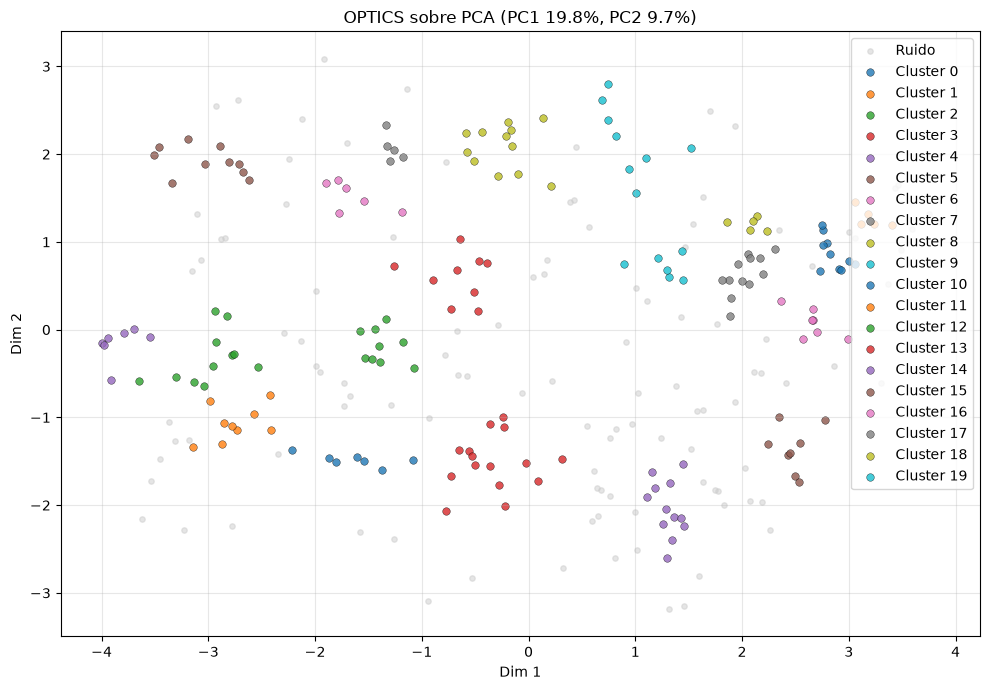

In [27]:
optics_pca, labels_pca, resumen_pca = run_optics(X_pca_2d, 'PCA')
plot_clusters(
    X_pca_2d, labels_pca,
    f'OPTICS sobre PCA (PC1 {varianza_individual[0]*100:.1f}%, PC2 {varianza_individual[1]*100:.1f}%)',
    'plots/4_mineria/optics_pca.png'
)

=== OPTICS UMAP ===
  Hiperparametros: min_samples=5, xi=0.05
  Clusters detectados: 27
  Ruido (label -1): 47 (16.5%)
  Silhouette (sin ruido): 0.567
  Tamanos por cluster: {-1: np.int64(47), 0: np.int64(6), 1: np.int64(5), 2: np.int64(12), 3: np.int64(6), 4: np.int64(7), 5: np.int64(6), 6: np.int64(10), 7: np.int64(6), 8: np.int64(9), 9: np.int64(7), 10: np.int64(9), 11: np.int64(11), 12: np.int64(11), 13: np.int64(9), 14: np.int64(6), 15: np.int64(8), 16: np.int64(6), 17: np.int64(10), 18: np.int64(15), 19: np.int64(10), 20: np.int64(10), 21: np.int64(17), 22: np.int64(6), 23: np.int64(13), 24: np.int64(5), 25: np.int64(10), 26: np.int64(7)}


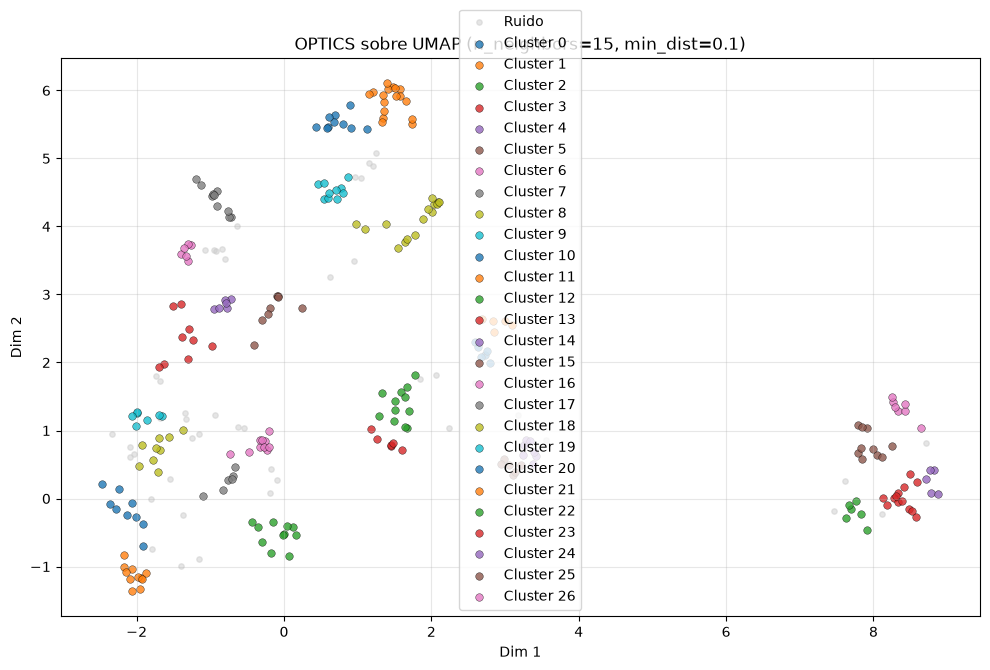

In [28]:
if umap_ok:
    optics_umap, labels_umap, resumen_umap = run_optics(X_umap, 'UMAP')
    plot_clusters(
        X_umap, labels_umap,
        'OPTICS sobre UMAP (n_neighbors=15, min_dist=0.1)',
        'plots/4_mineria/optics_umap.png'
    )
else:
    print('UMAP no disponible.')

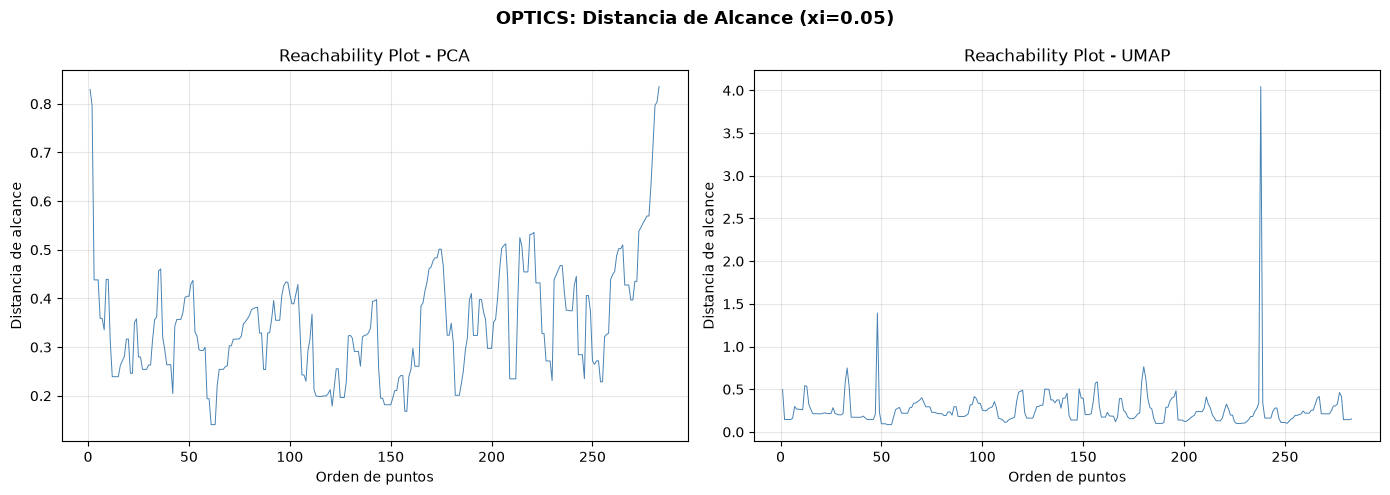

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) if umap_ok else (None, None)
if umap_ok:
    for ax, optics, nombre in zip(axes, [optics_pca, optics_umap], ['PCA', 'UMAP']):
        ord_ = optics.ordering_
        ax.plot(np.arange(len(ord_)), optics.reachability_[ord_], linewidth=0.7, color='steelblue')
        ax.set_title(f'Reachability Plot - {nombre}')
        ax.set_xlabel('Orden de puntos')
        ax.set_ylabel('Distancia de alcance')
        ax.grid(alpha=0.3)
    plt.suptitle('OPTICS: Distancia de Alcance (xi=0.05)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/4_mineria/optics_reachability.png', dpi=150)
    plt.show()
else:
    ord_ = optics_pca.ordering_
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(len(ord_)), optics_pca.reachability_[ord_], linewidth=0.7, color='steelblue')
    plt.title('Reachability Plot - PCA')
    plt.xlabel('Orden de puntos')
    plt.ylabel('Distancia de alcance')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/4_mineria/optics_reachability.png', dpi=150)
    plt.show()

In [30]:
filas = {'PCA': resumen_pca}
if umap_ok:
    filas['UMAP'] = resumen_umap
df_optics = pd.DataFrame(filas).T
df_optics['Ganador'] = df_optics['Silhouette'].idxmax()

print('=== OPTICS: COMPARACION PCA vs UMAP ===')
print(df_optics.round(3))

mejor = df_optics['Ganador'].iloc[0]
print(f'\n=> La proyeccion con mejor silhouette en OPTICS es {mejor}.')
if mejor == 'UMAP' and umap_ok:
    print('=> Coherente con la conclusion de la reduccion de dimensionalidad.')
else:
    print('=> Pese a las metricas de preservacion, PCA da clusters mas compactos.')

=== OPTICS: COMPARACION PCA vs UMAP ===
      Clusters  Ruido (%)  Silhouette  Tam min  Tam max Ganador
PCA       20.0       39.1       0.546      5.0     15.0    UMAP
UMAP      27.0       16.5       0.567      5.0     17.0    UMAP

=> La proyeccion con mejor silhouette en OPTICS es UMAP.
=> Coherente con la conclusion de la reduccion de dimensionalidad.


## Interpretacion del clustering

- **Clusters detectados**: cuantos grupos de pacientes encontro OPTICS en cada proyeccion.
- **Ruido (%)**: pacientes que OPTICS no asigna a ningun cluster (etiqueta `-1`). Un ruido alto sugiere ausencia de estructura de densidad clara.
- **Silhouette (sin ruido)**: compactitud y separacion de los clusters; se calcula excluyendo los puntos de ruido porque la metrica no admite la etiqueta `-1`.
- **Tamanos**: `Tam min`/`Tam max` informan si hay grupos muy desiguales (perfiles clinicos raros vs. mayoritarios).

> Completar la interpretacion con los valores que entreguen las celdas de ejecucion.


=== OPTICS PCA: metricas adicionales (sin ruido) ===
Davies-Bouldin         0.568
Calinski-Harabasz    506.857
ARI                    0.038
Dunn                   0.138
dtype: float64

=== OPTICS UMAP: metricas adicionales (sin ruido) ===
Davies-Bouldin          0.552
Calinski-Harabasz    2194.088
ARI                     0.036
Dunn                    0.111
dtype: float64

=== COMPARACION FINAL: K-Means vs OPTICS (PCA vs UMAP) ===
               Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI  \
K-Means PCA    399.005       0.447           0.788            338.214  0.177   
OPTICS PCA         NaN       0.546           0.568            506.857  0.038   
K-Means UMAP  1687.062       0.641           0.378            440.848 -0.086   
OPTICS UMAP        NaN       0.567           0.552           2194.088  0.036   

               Dunn  Clusters  Ruido (%)  Tam min  Tam max  
K-Means PCA   0.046       NaN        NaN      NaN      NaN  
OPTICS PCA    0.138      20.0       39.1   

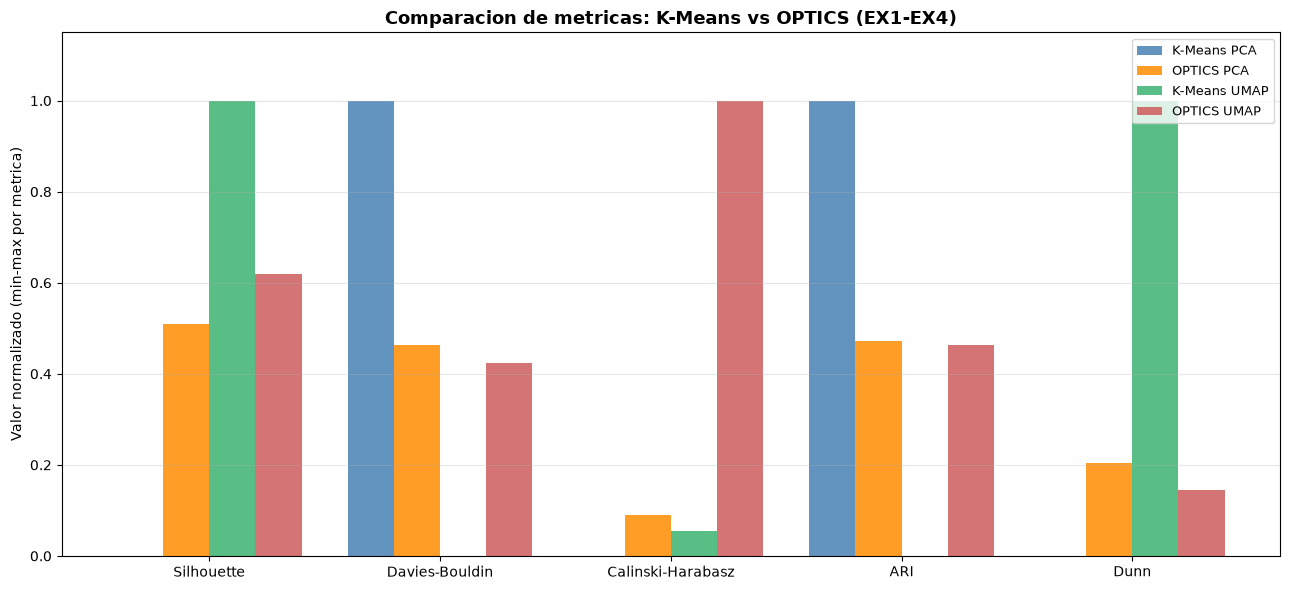

In [31]:
def extra_metrics(X, labels, y_true):
    mask = labels != -1
    res = {}
    if len(np.unique(labels[mask])) >= 2:
        res['Davies-Bouldin'] = davies_bouldin_score(X[mask], labels[mask])
        res['Calinski-Harabasz'] = calinski_harabasz_score(X[mask], labels[mask])
        res['ARI'] = adjusted_rand_score(np.asarray(y_true)[mask], labels[mask])
        res['Dunn'] = dunn_index(X[mask], labels[mask])
    return res

m_optics_pca = extra_metrics(X_pca_2d, labels_pca, y)
print('=== OPTICS PCA: metricas adicionales (sin ruido) ===')
print(pd.Series(m_optics_pca).round(3))

filas_comp = {
    'K-Means PCA': grid_pca.loc[k_opt_pca].to_dict(),
    'OPTICS PCA': {**resumen_pca, **m_optics_pca},
}
if umap_ok:
    m_optics_umap = extra_metrics(X_umap, labels_umap, y)
    print('\n=== OPTICS UMAP: metricas adicionales (sin ruido) ===')
    print(pd.Series(m_optics_umap).round(3))
    filas_comp['K-Means UMAP'] = grid_umap.loc[k_opt_umap].to_dict()
    filas_comp['OPTICS UMAP'] = {**resumen_umap, **m_optics_umap}

df_comp = pd.DataFrame(filas_comp).T
print('\n=== COMPARACION FINAL: K-Means vs OPTICS (PCA vs UMAP) ===')
print(df_comp.round(3))

metricas_grafico = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI', 'Dunn']
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metricas_grafico))
width = 0.2
colores = ['steelblue', 'darkorange', 'mediumseagreen', 'indianred']
valores_brutos = {m: [filas_comp[mod].get(m, np.nan) for mod in filas_comp] for m in metricas_grafico}
for i, modelo in enumerate(filas_comp):
    vals = []
    for m in metricas_grafico:
        v = valores_brutos[m][i]
        rng = np.nanmax(valores_brutos[m]) - np.nanmin(valores_brutos[m])
        vals.append((v - np.nanmin(valores_brutos[m])) / rng if rng > 0 and np.isfinite(v) else np.nan)
    ax.bar(x + (i - 1.5) * width, vals, width, label=modelo, color=colores[i], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metricas_grafico)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor normalizado (min-max por metrica)')
ax.set_title('Comparacion de metricas: K-Means vs OPTICS (EX1-EX4)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/5_evaluacion/clustering_metrics.png', dpi=150)
plt.show()


# Referencias

- Ankerst, M., Breunig, M. M., Kriegel, H.-P., & Sander, J. (1999). OPTICS: Ordering points to identify the clustering structure. *ACM SIGMOD Record*, 28(2), 49-60.
- Calinski, T., & Harabasz, J. (1974). A dendrite method for cluster analysis. *Communications in Statistics*, 3(1), 1-27.
- Cattell, R. B. (1966). The scree test for the number of factors. *Multivariate Behavioral Research*, 1(2), 245-276.
- Davies, D. L., & Bouldin, D. W. (1979). A cluster separation measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224-227.
- Detrano, R., Janosi, A., et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304-310.
- Dunn, J. C. (1974). Well-separated clusters and optimal fuzzy partitions. *Journal of Cybernetics*, 4(1), 95-104.
- Hartigan, J. A., & Wong, M. A. (1979). Algorithm AS 136: A k-means clustering algorithm. *Applied Statistics*, 28(1), 100-108.
- Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology*, 24(6), 417-441.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193-218.
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- Kaiser, H. F. (1960). The application of electronic computers to factor analysis. *Educational and Psychological Measurement*, 20(1), 141-151.
- Lee, J. A., & Verleysen, M. (2009). Quality assessment of dimensionality reduction: Rank-based criteria. *Neurocomputing*, 72(7-9), 1431-1443.
- Lloyd, S. P. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory*, 28(2), 129-137.
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281-297.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. *arXiv preprint arXiv:1802.03426*.
- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559-572.
- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
- UCI Machine Learning Repository. Heart Disease Dataset. https://archive.ics.uci.edu/dataset/45/heart+disease
- Vinh, N. X., Epps, J., & Bailey, J. (2010). Information theoretic measures for clusterings comparison: Variants, properties, normalization and correction for chance. *Journal of Machine Learning Research*, 11, 2837-2854.
